# What is an oscillator?

An **oscillator** is something that moves back and forth around a resting point. A simple example is an object attached to a spring. Pull the object, let it go, and it does not just move once and stop. It keeps moving back and forth around its resting position.

That back-and-forth motion is called **oscillation**. The resting position in the middle is called the **equilibrium position**. You can think of it as the place the object would like to return to, even though its momentum keeps carrying it past that point.

In a perfectly ideal model, the object would keep oscillating forever. Real systems are less generous. Friction, air resistance, and other losses slowly drain energy from the motion, so the oscillation gradually fades. That gradual slowing is called **damping**.

![Image of a mass-spring system](./simple_mass_spring.png)

## The basic model

Here is the first mathematical version of the story. A **harmonic oscillator** describes an ideal oscillator with no damping and no external force pushing on it:
$$\frac{d^2x}{dt^2} + \omega^2 x = 0$$
Here, $x$ is the displacement from equilibrium, $t$ is time, and $\omega=\sqrt{\frac{k}{m}}$ is the angular frequency. The solution is sinusoidal motion: the familiar repeating wave we expect from a spring-like system.

Now let's make the model a little more realistic by adding damping:
$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega^2 x = 0$$
where $\beta$ is the damping coefficient. Depending on this value, the oscillator may keep ringing for a while, return smoothly to rest, or settle as quickly as possible without overshooting.

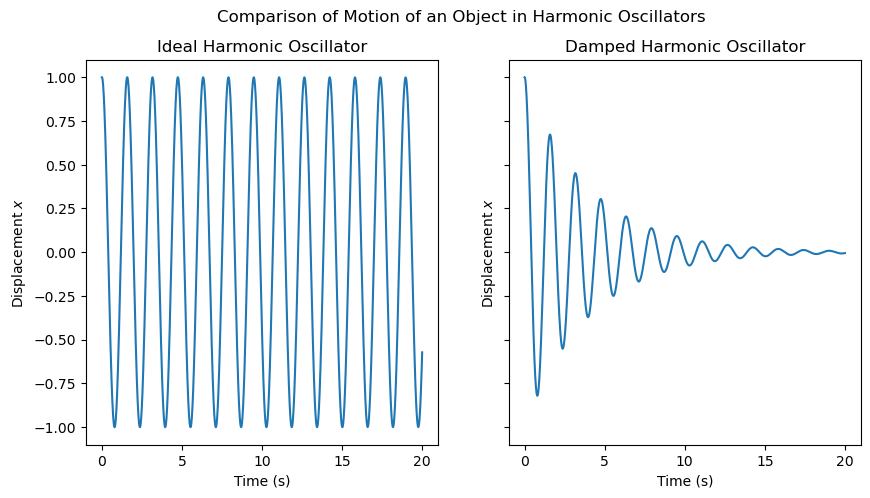

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def harmonic_oscillator(t, y, omega):
    x, v = y
    dxdt = v
    dvdt = -omega**2 * x
    return [dxdt, dvdt]

def damped_harmonic_oscillator(t, y, omega, beta):
    x, v = y
    dxdt = v
    dvdt = -beta * v - omega**2 * x
    return [dxdt, dvdt]

# Parameters
A = 1.0      # Amplitude
k = 4 * np.pi**2  # Spring constant
m = 2.5      # Mass
omega = np.sqrt(k / m)  # Natural frequency
beta = 0.5  # Damping coefficient for underdamped case
t = np.linspace(0, 20, 2000)  # Time array

# Initial condition
y = [A, 0]  # Initial displacement and velocity

# Compute the damped harmonic oscillator
x_ideal = solve_ivp(harmonic_oscillator, (t[0], t[-1]), y, args=(omega,), t_eval=t).y[0]
x_under = solve_ivp(damped_harmonic_oscillator, (t[0], t[-1]), y, args=(omega, beta), t_eval=t).y[0]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t, x_ideal)
ax[0].set_title('Ideal Harmonic Oscillator')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Displacement $x$')

ax[1].plot(t, x_under)
ax[1].set_title('Damped Harmonic Oscillator')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Displacement $x$')

fig.suptitle('Comparison of Motion of an Object in Harmonic Oscillators')
plt.show()

So far, we have only nudged the oscillator and watched what it does on its own. No one keeps pushing it after the initial start. That is called **free oscillation**.

But what if we keep feeding the system an input while it moves? That gives us **forced oscillation**, where an outside signal keeps influencing the oscillator:

$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega^2 x = f(t)$$

Here, $f(t)$ is the external driving force. You can think of it as the signal we are injecting into the system.

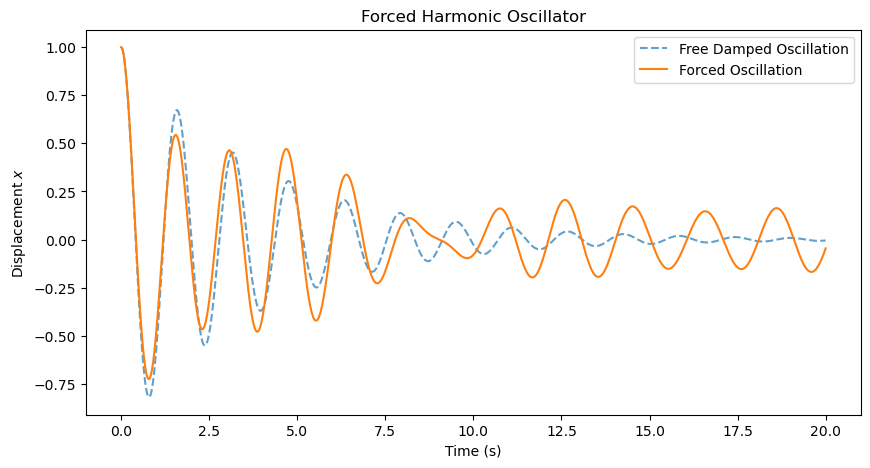

In [2]:
def forced_harmonic_oscillator(t, y, omega, beta, F0, omega_d):
    x, v = y
    dxdt = v
    Ft = F0 * np.sin(omega_d * t)
    dvdt = (Ft / m) - beta * v - omega**2 * x
    return [dxdt, dvdt]

# Parameters for forced oscillator
F0 = 2.5  # Amplitude of driving force
omega_d = np.pi  # Driving frequency

# Compute the forced harmonic oscillator
x_forced = solve_ivp(forced_harmonic_oscillator, (t[0], t[-1]), y, args=(omega, beta, F0, omega_d), t_eval=t).y[0]

# Plotting the forced harmonic oscillator
plt.figure(figsize=(10, 5))
plt.plot(t, x_under, '--', label='Free Damped Oscillation', alpha=0.7)
plt.plot(t, x_forced, label='Forced Oscillation')
plt.title('Forced Harmonic Oscillator')
plt.xlabel('Time (s)')
plt.ylabel('Displacement $x$')
plt.legend()
plt.show()

Now the oscillator has someone keeping it company. A periodic driving force can keep the motion going longer because it adds energy back into the system, partly replacing what damping removes. The exact motion depends on the frequency and amplitude of the driving force, along with the oscillator's own natural frequency and damping.

So far, that input has come from outside the oscillator. But here is the next twist: an oscillator can also be pushed around by another oscillator. If two moving systems are connected, the motion of one becomes part of the force felt by the other. That idea leads us naturally to **coupled oscillators**.

# Coupled Oscillators

A coupled oscillator system contains two or more oscillators whose motions affect one another. The connection might be mechanical, like a spring between two masses, or it might come through electrical circuits, sound waves, or another shared medium.

For now, let's stick with a spring coupling like this one:

![Image of two coupled oscillators](./coupled_oscillator.png)

The important part is not just that there are two masses. It is that their motions are now linked. If one oscillator is displaced from equilibrium, it can tug on the other and make that one move too. The coupling gives energy and information a path through the system.

Mathematically, this means the equations have to talk to each other as well. For two coupled oscillators, one simple model is:
$$\frac{d^2x_1}{dt^2} + \beta_1 \frac{dx_1}{dt} + \omega_1^2 x_1 = f_1(t) + c_{12} (x_2 - x_1) $$
$$\frac{d^2x_2}{dt^2} + \beta_2 \frac{dx_2}{dt} + \omega_2^2 x_2 = f_2(t) + c_{12} (x_1 - x_2) $$
Here, $x_1$ and $x_2$ are the displacements of the two oscillators, $c_{12}$ is the coupling constant, $\beta_1$ and $\beta_2$ are damping coefficients, $\omega_1$ and $\omega_2$ are natural frequencies, and $f_1(t)$ and $f_2(t)$ are external driving forces. The new piece is the coupling term: each oscillator now feels the other one's motion.

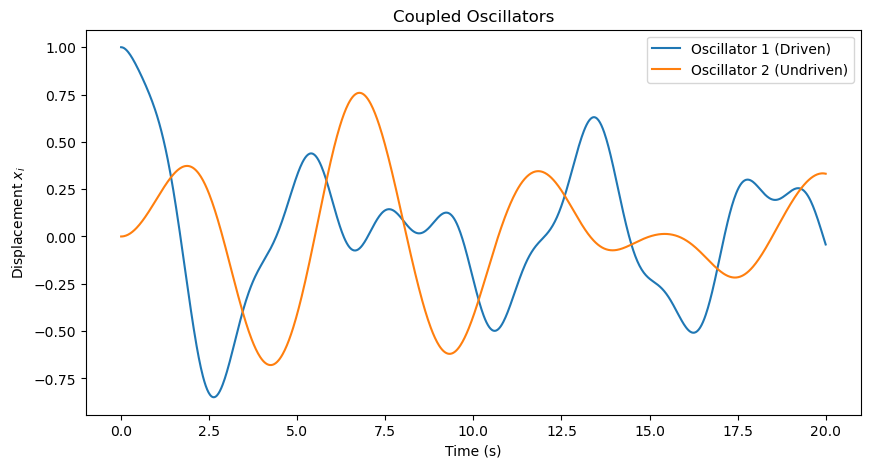

In [3]:
def coupled_oscillators(t, y, k, m, beta, c12, F0_1, F0_2, omega_d_1, omega_d_2):
    x1, v1, x2, v2 = y
    F1 = F0_1 * np.sin(omega_d_1 * t)
    F2 = F0_2 * np.sin(omega_d_2 * t)
    dx1dt = v1
    dv1dt = -beta * v1 - (k/m) * x1 + c12 * (x2 - x1) + F1 / m
    dx2dt = v2
    dv2dt = -beta * v2 - (k/m) * x2 + c12 * (x1 - x2) + F2 / m
    return [dx1dt, dv1dt, dx2dt, dv2dt]

# Parameters for coupled oscillators
k = 1.0  # Coupling strength
m = 1.0  # Mass of each oscillator
omega = np.sqrt(k / m)  # Natural frequency of each oscillator
beta = 0.1  # Damping coefficient for underdamped case
c12 = 0.5  # Coupling constant
F0_1 = 1.0  # Amplitude of driving force for oscillator 1
F0_2 = 0.0  # Amplitude of driving force for oscillator 2
omega_d_1 = np.pi  # Driving frequency for oscillator 1
omega_d_2 = np.pi  # Driving frequency for oscillator 2
y0 = [1.0, 0.0, 0.0, 0.0]  # Initial conditions: [x1, v1, x2, v2]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

# Solve the coupled oscillators
sol = solve_ivp(coupled_oscillators, t_span, y0, args=(k, m, beta, c12, F0_1, F0_2, omega_d_1, omega_d_2), t_eval=t_eval)

# Plotting the coupled oscillators
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label='Oscillator 1 (Driven)')
plt.plot(sol.t, sol.y[2], label='Oscillator 2 (Undriven)')
plt.title('Coupled Oscillators')
plt.xlabel('Time (s)')
plt.ylabel('Displacement $x_i$')
plt.legend()
plt.show()

This plot is our first glimpse of a small oscillator network in motion. Even though only the first oscillator is directly driven, the other oscillator starts moving because the coupling passes that influence through the system. The traces are not identical, which is exactly the interesting part: the same input is being reshaped into several different responses.

This is still a rough version of the idea, though. The parameters are mostly chosen just to see the network move. Next, let's make the setup feel a little more like a reservoir we can actually use.

## What changes when we connect many oscillators?

Two oscillators are already interesting. But what happens if we connect many of them? Now a signal does not just move back and forth in one place. It spreads, mixes, fades, and reappears across the whole system.

That is the opening we need for **physical reservoir computing**. Under the right conditions, a network of coupled oscillators can act like a physical reservoir: the input signal creates a rich pattern of internal motion, and a simple output model can learn to use that pattern for tasks such as signal processing, pattern recognition, or other machine-learning-style problems.

If we have $N$ oscillators, each oscillator has its own displacement, damping, natural frequency, input, and connections to the others. One way to write the motion of the $i^{th}$ oscillator is:

$$\frac{d^2x_i}{dt^2} + \beta_i \frac{dx_i}{dt} + \omega_i^2 x_i = f_i(t) + \sum_{j=1}^{N} c_{ij} (x_j - x_i)$$

Here, $x_i$ is the displacement, $\beta_i$ is the damping coefficient, $\omega_i$ is the natural frequency, $f_i(t)$ is the external driving force, and $c_{ij}$ is the coupling strength between oscillator $i$ and oscillator $j$. The sum is the important part: it gathers the influence of the rest of the network on oscillator $i$.

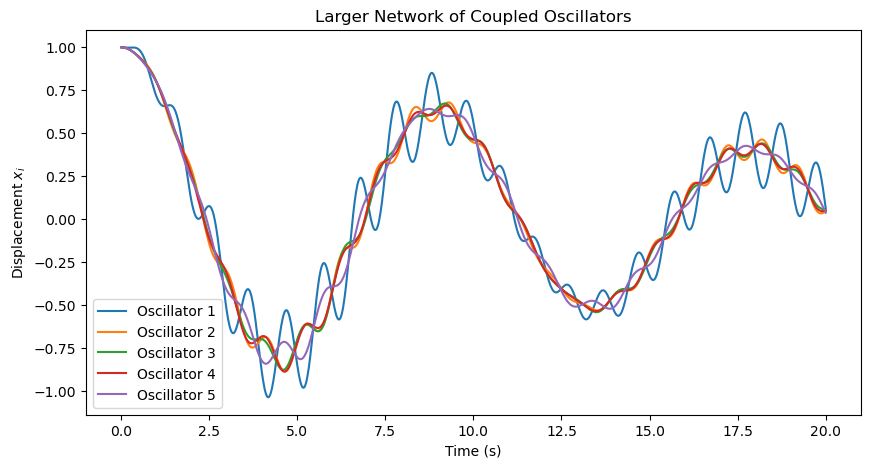

In [4]:
def coupled_oscillators(t, y, k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix):
    N = len(y) // 2
    x = y[:N]
    v = y[N:]

    dxdt = v
    dvdt = np.zeros(N)
    for i in range(N):
        Ft = F_matrix[i] * np.sin(omega_d * t)
        coupling_term = sum(c_matrix[i, j] * (x[j] - x[i]) for j in range(N))
        dvdt[i] = - beta_matrix[i] * v[i] - (k_matrix[i, i] / m) * x[i] + coupling_term + Ft / m
    
    
    return np.concatenate([dxdt, dvdt])

# Parameters for a larger network of coupled oscillators
N = 5  # Number of oscillators
k_matrix = np.full((N, N), 0.5)  # Spring constant matrix
m = 1.0  # Mass of each oscillator
beta_matrix = np.full(N, 0.1)  # Damping coefficients

F0 = 1.0
omega_d = 2 * np.pi  # Driving frequency
seed = 56
rng = np.random.default_rng(seed)
F_matrix = np.zeros(N)
F_matrix[0:1] = 1.0  # Only the first oscillator is driven, others are passive
# F_matrix = np.random.rand(N)# * 2 * np.pi  # Random driving frequencies
seed = 268
rng = np.random.default_rng(seed)
c_matrix = rng.uniform(0, 10, (N, N))  # Random coupling strengths
y0 = np.concatenate([np.ones(N), np.zeros(N)])  # Initial conditions: [x1, x2, ..., v1, v2, ...]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

# Solve the larger network of coupled oscillators
sol = solve_ivp(coupled_oscillators, t_span, y0, args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix), t_eval=t_eval)

# Plotting the larger network of coupled oscillators
plt.figure(figsize=(10, 5))
for i in range(N):
    plt.plot(sol.t, sol.y[i], label=f'Oscillator {i+1}')
plt.title('Larger Network of Coupled Oscillators')
plt.xlabel('Time (s)')
plt.ylabel('Displacement $x_i$')
plt.legend()
plt.show()

## Scaling up the reservoir

The previous example was deliberately small and a bit rough: only a few oscillators, with randomly chosen parameters. Now let's make the setup feel more like a reservoir. We will use more oscillators, choose the parameters more carefully, and drive the system with a shared input signal.

In this version, the input enters through the first oscillator. The others do not receive it directly; they feel it through the coupling. That is exactly what we want to watch: how does one signal ripple through the system and turn into many different internal responses?

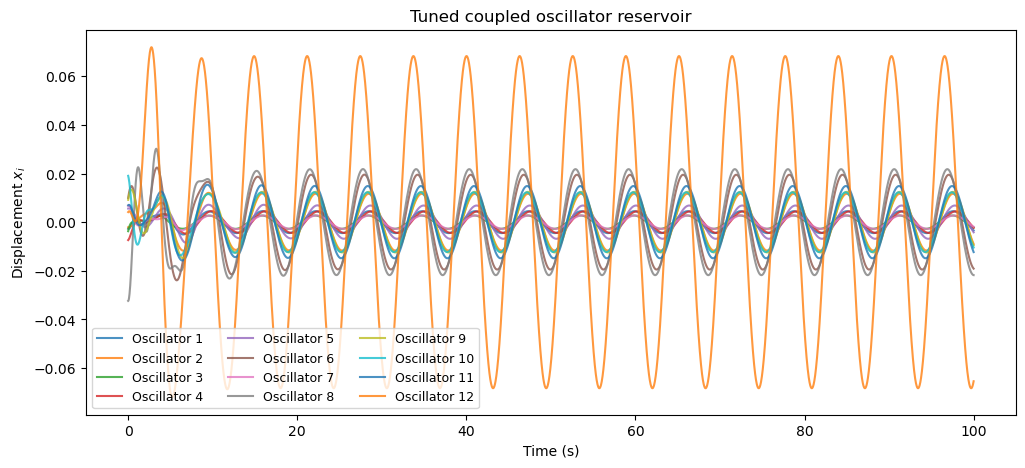

In [5]:
import scipy

def drive_signal(t, omega_d):
    return np.sin(omega_d * t)

def coupled_oscillators(t, y, k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix):
    N = len(y) // 2
    x = y[:N]
    v = y[N:]

    dxdt = v

    u = drive_signal(t, omega_d)

    row_sums = c_matrix.sum(axis=1)
    coupling_term = c_matrix @ x - row_sums * x  # Efficient coupling term calculation

    dvdt = -beta_matrix * v - omega_n**2 * x + coupling_term + (F_matrix * F0 * u) / m

    return np.concatenate([dxdt, dvdt])

def make_coupling_matrix(N, density, coupling_strength, omega_n, rng):
    A = rng.random((N, N)) < density
    A = np.triu(A, 1)
    A = A + A.T

    weights = rng.uniform(0.5, 1.5, size=(N, N))
    c_matrix = A * weights

    row_sums = c_matrix.sum(axis=1)
    max_row_sum = row_sums.max()

    if max_row_sum > 0:
        target_row_sum = coupling_strength * np.median(omega_n**2)
        c_matrix *= target_row_sum / max_row_sum

    np.fill_diagonal(c_matrix, 0.0)
    return c_matrix

# Tuned parameters for a bounded, diverse reservoir response
N = 128
m = 1.0
seed = 56
rng = np.random.default_rng(seed)

zeta_matrix = rng.uniform(0.3, 1.0, N)
omega_n = np.exp(rng.uniform(np.log(0.3), np.log(5.0), N))
k_matrix = np.diag(m * omega_n**2)
beta_matrix = 2 * m * zeta_matrix * omega_n

omega_d = 1.0  # Driving frequency
F0 = 2.5
F_matrix = np.zeros(N)
input_nodes = np.array([0])  # Only the first oscillator is driven
readout_nodes = np.arange(1, N)  # All oscillators are read out except the first one
F_matrix[input_nodes] = 1.0  # Only the first oscillator is driven, others are passive

seed = 268
rng = np.random.default_rng(seed)
c_matrix = make_coupling_matrix(N, density=0.1, coupling_strength=10, omega_n=omega_n, rng=rng)

y0 = 0.01 * rng.standard_normal(2 * N)
t_span = (0.0, 100.0)
t_eval = np.linspace(*t_span, 5000)

sol = solve_ivp(
    coupled_oscillators,
    t_span,
    y0,
    args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix),
    t_eval=t_eval,
    max_step=0.05,
    rtol=1e-6,
    atol=1e-8,
 )

assert sol.success, sol.message
X_sol = sol.y[:N].T
X = X_sol[:, readout_nodes]  # Read out only the passive oscillators
input_trace = drive_signal(sol.t, omega_d)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
for i in range(12):
    ax.plot(sol.t, X[:, i], label=f"Oscillator {i + 1}", alpha=0.8)
ax.set_title("Tuned coupled oscillator reservoir")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement $x_i$")
ax.legend(ncol=3, fontsize=9)
plt.show()

## Reconstructing the input signal from the oscillator states

Now the traces are not identical copies of the input. Each oscillator responds with its own amplitude and phase, giving us several related views of the same driving signal.

So here is the test: if we look only at these oscillator states, can we reconstruct the signal that originally drove the system?

### How do we do that?
We are going to collect the states that is, the displacements of all the oscillators in the system from 0 to 100 seconds. We will use 70% of that data to obtain the mapping from the oscillator states to the input signal, and then we will test how well that mapping works on the remaining 30% of the data. If the reservoir is doing a good job, then we should be able to reconstruct the input signal from the internal states with high accuracy.

Task: Delayed input reconstruction (delay = 0.000 s)
R^2: 0.989/1.0


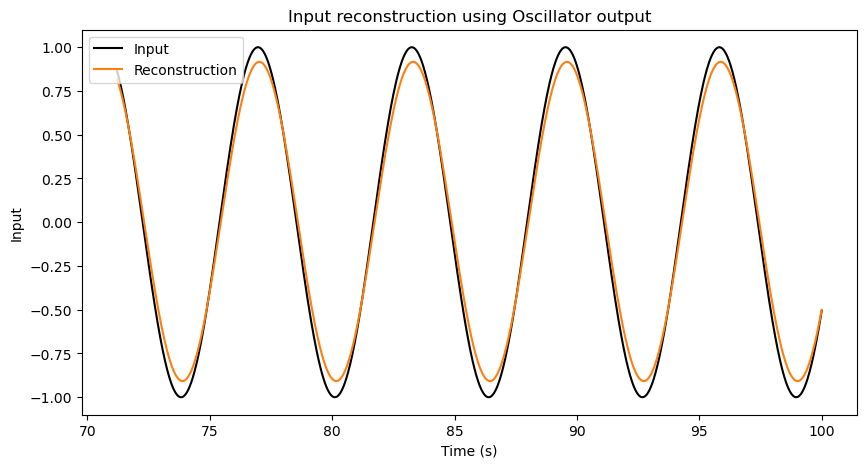

In [6]:
from sklearn.metrics import r2_score, mean_squared_error

def __fit__(X_eval, u_eval, train_size, ridge_alpha):
    X_train = X_eval[:train_size]
    X_test = X_eval[train_size:]
    y_train = u_eval[:train_size]
    y_train = y_train.T
    y_test = u_eval[train_size:]
    y_test = y_test.T

    X_train_aug = np.column_stack([X_train, np.ones(len(X_train))]).T
    X_test_aug = np.column_stack([X_test, np.ones(len(X_test))]).T

    ridge = np.matmul(X_train_aug, X_train_aug.T) + ridge_alpha * np.identity(X_train_aug.shape[0])
    ridge_inv = np.linalg.inv(ridge)
    yX = np.matmul(y_train, X_train_aug.T)
    Wout = np.matmul(yX, ridge_inv.T)

    y_pred = Wout @ X_test_aug
    baseline_pred = np.full_like(y_test, y_train.mean())

    score = r2_score(y_true=y_test.T, y_pred=y_pred.T)
    print(f"R^2: {score:.3f}/1.0")

    return y_test, y_pred, score, Wout

# Delayed input reconstruction on the tuned reservoir states
washout = 200
delay_steps = 0
train_fraction = 0.7
ridge_alpha = 2

print(f"Task: Delayed input reconstruction (delay = {delay_steps * (t_eval[1] - t_eval[0]):.3f} s)")

X_eval = X[washout:]
u_eval = input_trace[washout:]
u_eval = u_eval[:, np.newaxis]

if delay_steps >= len(u_eval):
    raise ValueError("delay_steps is too large for the available time series length.")

X_delayed = X_eval[delay_steps:]
u_target = u_eval[:-delay_steps] if delay_steps > 0 else u_eval

n_samples = len(u_target)
train_size = int(train_fraction * n_samples)

y_test, y_pred, score, _ = __fit__(X_delayed, u_target, train_size, ridge_alpha)

test_time = sol.t[washout + delay_steps + train_size : washout + delay_steps + n_samples]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(test_time, y_test.T, label="Input", color="black", linewidth=1.5)
ax.plot(test_time, y_pred.T, label="Reconstruction", color="tab:orange")
ax.set_title("Input reconstruction using Oscillator output")
ax.set_ylabel("Input")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()

Okay, great! This system can reconstruct a simple sine wave input signal. Quantitavely, this reconstuction has a score of 0.989 out of 1. That is pretty good, even though not perfect. 

But we should not celebrate too quickly. A single sine wave is a very simple signal as it keeps repeating periodically. It is not a real test of the system's ability to process complex information. To really see the potential of this reservoir, we need to try it with more complicated inputs and more challenging tasks.

## A harder input signal

This time, let's dirve the first oscillator with an input signal that is a sum of 3 sine waves with different frequencies. This is a more complex signal that contains more information than a single sine wave and also does not repeat.

Task: Delayed input reconstruction (delay = 0.000 s)
R^2: 0.736/1.0


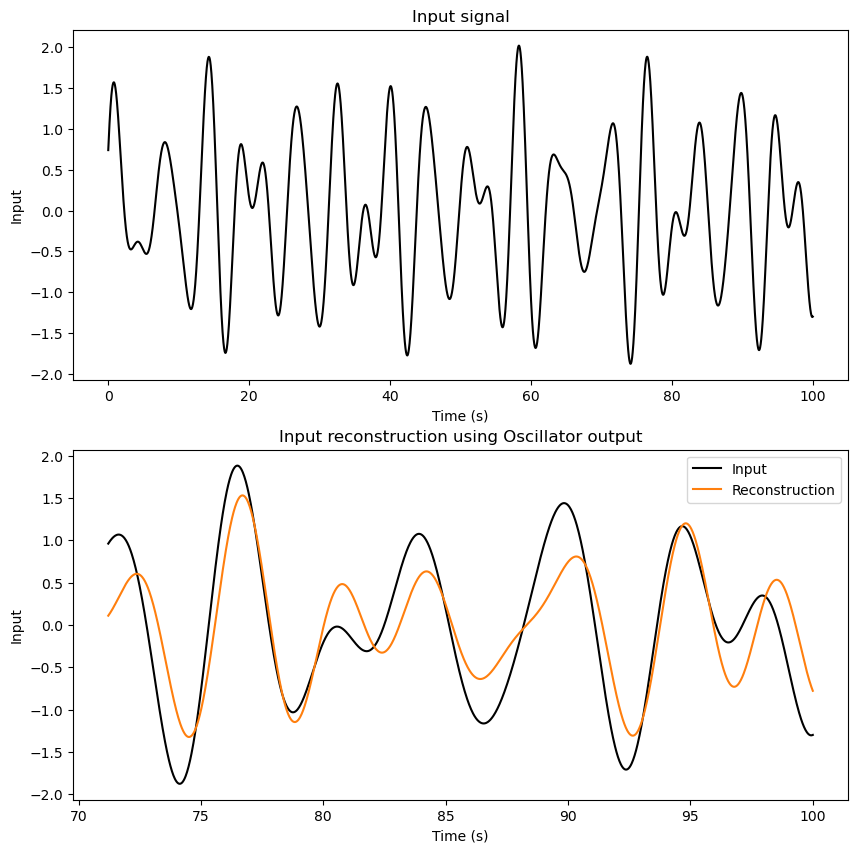

In [7]:
def drive_signal(t, omega_d):
    t = np.asarray(t)
    return (
        np.sin(omega_d * t) + 0.65 * np.sin(np.sqrt(2) * omega_d * t + 0.6) + 0.4 * np.sin(np.sqrt(3) * omega_d * t + 1.2)
    )

sol = solve_ivp(
    coupled_oscillators,
    t_span,
    y0,
    args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix),
    t_eval=t_eval,
    max_step=0.05,
    rtol=1e-6,
    atol=1e-8,
 )

assert sol.success, sol.message
X_sol = sol.y[:N].T
X = X_sol[:, readout_nodes]  # Read out only the passive oscillators
input_trace = drive_signal(sol.t, omega_d)

# Input reconstruction on the tuned reservoir states
washout = 200
delay_steps = 0
train_fraction = 0.7
ridge_alpha = 2

print(f"Task: Delayed input reconstruction (delay = {delay_steps * (t_eval[1] - t_eval[0]):.3f} s)")

X_eval = X[washout:]
u_eval = input_trace[washout:]
u_eval = u_eval[:, np.newaxis]

if delay_steps >= len(u_eval):
    raise ValueError("delay_steps is too large for the available time series length.")

X_delayed = X_eval[delay_steps:]
u_target = u_eval[:-delay_steps] if delay_steps > 0 else u_eval

n_samples = len(u_target)
train_size = int(train_fraction * n_samples)

y_test, y_pred, score, _ = __fit__(X_delayed, u_target, train_size, ridge_alpha)

test_time = sol.t[washout + delay_steps + train_size : washout + delay_steps + n_samples]

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].plot(sol.t, input_trace, label="Input", color="black", linewidth=1.5)
ax[0].set_title("Input signal")
ax[0].set_ylabel("Input")
ax[0].set_xlabel("Time (s)")

ax[1].plot(test_time, y_test.T, label="Input", color="black", linewidth=1.5)
ax[1].plot(test_time, y_pred.T, label="Reconstruction", color="tab:orange")
ax[1].set_title("Input reconstruction using Oscillator output")
ax[1].set_ylabel("Input")
ax[1].set_xlabel("Time (s)")
ax[1].legend()
plt.show()

This reconstruction is not where we want it to be. That is useful information, not a failure. It tells us that this particular reservoir setup is not capturing enough of the signal structure for the output model to recover it well.

So let's tune the system and see what changes.

## Tuning the reservoir response

I am going to increase the coupling strength, the driving force, and the driving frequency, then compare the result.

Task: Delayed input reconstruction (delay = 0.000 s)
R^2: 0.996/1.0


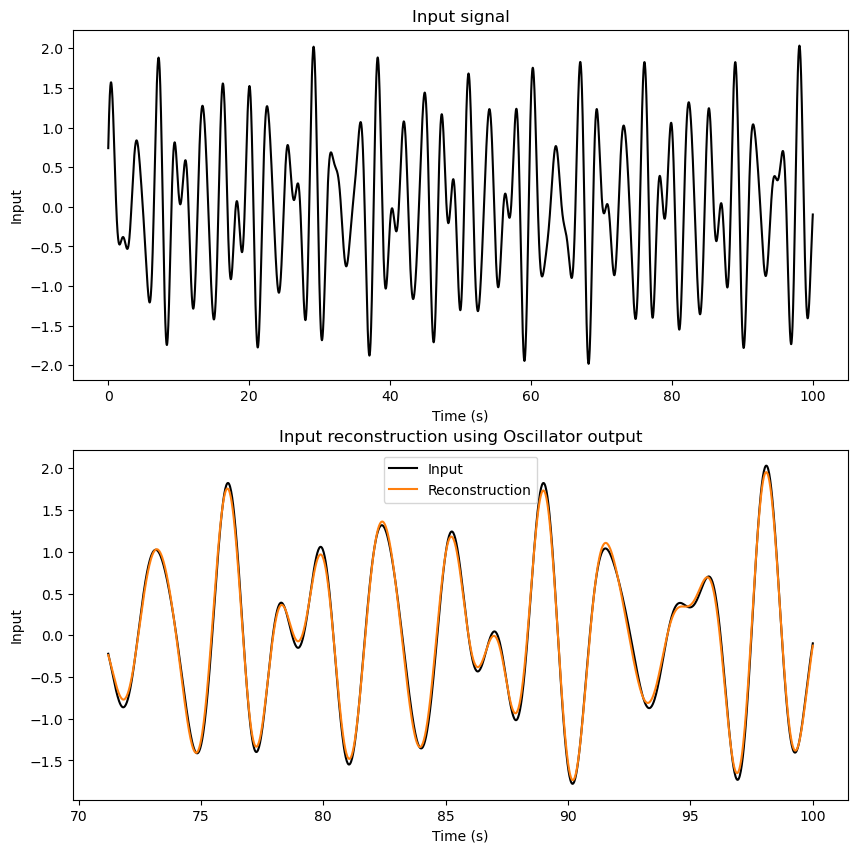

In [8]:
def drive_signal(t, omega_d):
    t = np.asarray(t)
    return (
        np.sin(omega_d * t) + 0.65 * np.sin(np.sqrt(2) * omega_d * t + 0.6) + 0.4 * np.sin(np.sqrt(3) * omega_d * t + 1.2)
    )

# Tuned parameters for a bounded, diverse reservoir response
N = 128
m = 1.0
seed = 56
rng = np.random.default_rng(seed)

zeta_matrix = rng.uniform(0.3, 1.0, N)
omega_n = np.exp(rng.uniform(np.log(0.3), np.log(5.0), N))
k_matrix = np.diag(m * omega_n**2)
beta_matrix = 2 * m * zeta_matrix * omega_n

omega_d = 2.0  # Driving frequency
F0 = 10
F_matrix = np.zeros(N)
input_nodes = np.array([0])  # Only the first oscillator is driven
readout_nodes = np.arange(1, N)  # All oscillators are read out except the first one
F_matrix[input_nodes] = 1.0  # Only the first oscillator is driven, others are passive

seed = 268
rng = np.random.default_rng(seed)
c_matrix = make_coupling_matrix(N, density=0.1, coupling_strength=20, omega_n=omega_n, rng=rng)

y0 = 0.01 * rng.standard_normal(2 * N)
t_span = (0.0, 100.0)
t_eval = np.linspace(*t_span, 5000)

sol = solve_ivp(
    coupled_oscillators,
    t_span,
    y0,
    args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix),
    t_eval=t_eval,
    max_step=0.05,
    rtol=1e-6,
    atol=1e-8,
 )

assert sol.success, sol.message
X_sol = sol.y[:N].T
X = X_sol[:, readout_nodes]  # Read out only the passive oscillators
input_trace = drive_signal(sol.t, omega_d)

# Input reconstruction on the tuned reservoir states
washout = 200
delay_steps = 0
train_fraction = 0.7
ridge_alpha = 2

print(f"Task: Delayed input reconstruction (delay = {delay_steps * (t_eval[1] - t_eval[0]):.3f} s)")

X_eval = X[washout:]
u_eval = input_trace[washout:]
u_eval = u_eval[:, np.newaxis]

if delay_steps >= len(u_eval):
    raise ValueError("delay_steps is too large for the available time series length.")

X_delayed = X_eval[delay_steps:]
u_target = u_eval[:-delay_steps] if delay_steps > 0 else u_eval

n_samples = len(u_target)
train_size = int(train_fraction * n_samples)

y_test, y_pred, score, _ = __fit__(X_delayed, u_target, train_size, ridge_alpha)

test_time = sol.t[washout + delay_steps + train_size : washout + delay_steps + n_samples]

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].plot(sol.t, input_trace, label="Input", color="black", linewidth=1.5)
ax[0].set_title("Input signal")
ax[0].set_ylabel("Input")
ax[0].set_xlabel("Time (s)")

ax[1].plot(test_time, y_test.T, label="Input", color="black", linewidth=1.5)
ax[1].plot(test_time, y_pred.T, label="Reconstruction", color="tab:orange")
ax[1].set_title("Input reconstruction using Oscillator output")
ax[1].set_ylabel("Input")
ax[1].set_xlabel("Time (s)")
ax[1].legend()
plt.show()

Great! The reconstruction is much better now, with a score of 0.998 out of 1. That is a significant improvement, showing that the reservoir can capture more of the signal structure when we adjust the parameters.

So far, we have been asking the reservoir about the present: can the current state tell us what the input is right now?

But the more interesting question is about memory. Does the system carry traces of what happened a little while ago? Let's test that by asking whether the output model can reconstruct the input after a delay.

## Testing memory

Here, we follow the same procedure as before, but this time we obtain a mapping from the current oscillator states to the input signal from a few seconds ago.

I am going to set the delay to 1000 steps, which is about 20 seconds in this simulation. That means the output model will try to reconstruct the input signal from 20 seconds ago, using only the current state of the oscillator network.

Task: Delayed input reconstruction (delay = 20.004 s)
R^2: 0.993/1.0


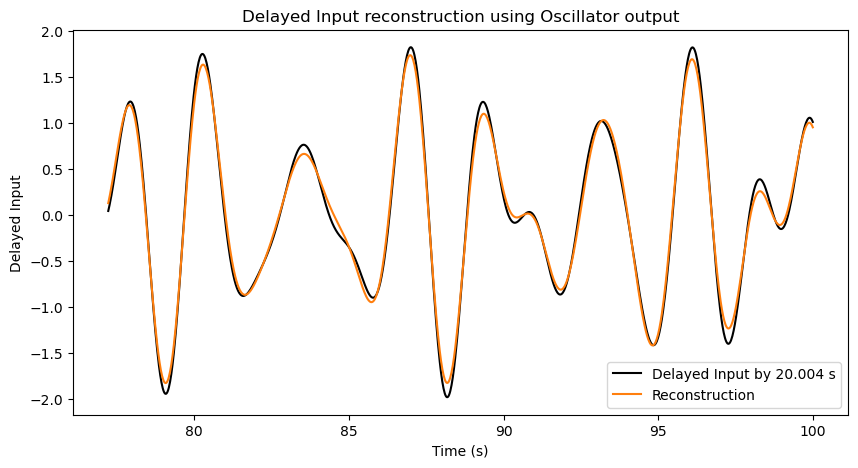

In [9]:
# Input reconstruction on the tuned reservoir states
delay_steps = 1000

print(f"Task: Delayed input reconstruction (delay = {delay_steps * (t_eval[1] - t_eval[0]):.3f} s)")

if delay_steps >= len(u_eval):
    raise ValueError("delay_steps is too large for the available time series length.")

X_delayed = X_eval[delay_steps:]
u_target = u_eval[:-delay_steps] if delay_steps > 0 else u_eval

n_samples = len(u_target)
train_size = int(train_fraction * n_samples)

y_test, y_pred, score, _ = __fit__(X_delayed, u_target, train_size, ridge_alpha)

test_time = sol.t[washout + delay_steps + train_size : washout + delay_steps + n_samples]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(test_time, y_test.T, label=f"Delayed Input by {delay_steps * (t_eval[1] - t_eval[0]):.3f} s", color="black", linewidth=1.5)
ax.plot(test_time, y_pred.T, label="Reconstruction", color="tab:orange")
ax.set_title("Delayed Input reconstruction using Oscillator output")
ax.set_ylabel("Delayed Input")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()

Wonderful! This system is able to reconstruct a delayed input signal very well for this input and parameter setting. This means that the reservoir is not just reacting to the current input, but also retaining information about recent input history.

### Why do we care about memory? 
Because this is a simple way to test whether the reservoir has memory. If the current state of the oscillator network still contains information from a few seconds ago, then the reservoir can support tasks where recent context matters. For example, if a robot is moving through a room, its next action should not depend only on what it sees right now. It also helps to know what it was seeing and doing a moment ago, because that recent history tells the robot whether it is approaching an object, moving away from it, or turning around.

Now let's make the task harder: can the current reservoir state help predict future values of the input signal over a short horizon?

## Predicting a short step ahead

### Why do we care about predicting the future? 

Because that is a common real-world task. If we can use the current state of the reservoir to predict what will happen next, then we can use this capability for anticipating events and making decisions based on what is likely to come. For example, if we are controlling a robot and we know what is going to happen in the next few seconds, we can plan our actions better. Or if we are monitoring a system and we can predict a failure before it happens which will allow us to take preventive measures.

### How can we predict the future?

This is a different task than reconstructing the past. I will first train the output model to predict the input signal 1 step ahead, which is about 20 milliseconds in this simulation. That means the output model will try to predict the input signal at the next time step, using only the current state of the oscillator network.

In [10]:
# Input reconstruction on the tuned reservoir states
washout = 200
train_fraction = 0.7
ridge_alpha = 2

X_eval = X[washout:]
u_eval = input_trace[washout:]
u_eval = u_eval[:, np.newaxis]

# Input reconstruction on the tuned reservoir states
future_steps = 1

print(f"Task: Future input prediction (steps = {future_steps})")

X_current = X_eval[:-future_steps]
u_target = u_eval[future_steps:] if future_steps > 0 else u_eval

n_samples = len(u_target)
train_size = int(train_fraction * n_samples)

_, _, _, Wout = __fit__(X_current, u_target, train_size, ridge_alpha)

Task: Future input prediction (steps = 1)
R^2: 0.997/1.0


Now that I have a prediction output model, I will use these predicted input values to drive my oscillator network for a few seconds. The question is: how well does the reservoir's internal state reflect the future input values that it is trying to predict? If the reservoir can capture the dynamics of the input signal, then the predicted future values should be reasonably close to the actual future values, and the internal states should show patterns that correspond to those predictions. Let's see how it goes! 

Future input prediction R^2: 0.940/1.0


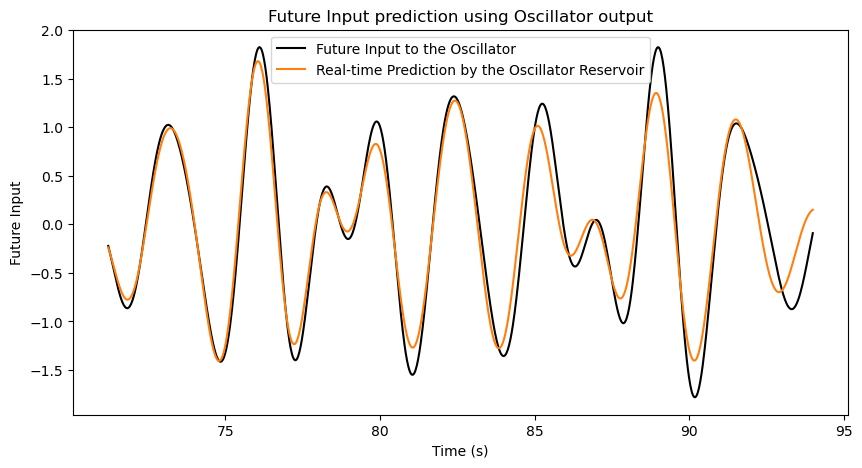

In [11]:
def coupled_oscillators_pred(t, y, k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix, drive_value):
    N = len(y) // 2
    x = y[:N]
    v = y[N:]

    dxdt = v

    u = drive_value

    row_sums = c_matrix.sum(axis=1)
    coupling_term = c_matrix @ x - row_sums * x  # Efficient coupling term calculation

    dvdt = -beta_matrix * v - omega_n**2 * x + coupling_term + (F_matrix * F0 * u) / m

    return np.concatenate([dxdt, dvdt])

def readout_prediction(X_current, Wout):
    X_current_aug = np.append(X_current, 1)
    y_pred = Wout @ X_current_aug
    return y_pred

y_current = sol.y[:, washout + future_steps + train_size-1].T.copy()
x_current = y_current[readout_nodes]
t_current = sol.t[washout + future_steps + train_size-1]
dt = t_eval[1] - t_eval[0]

input_pred_auto = []
t_pred_auto = []

for step in range(test_time.shape[0]):
    # Current displacement
    x_current = y_current[readout_nodes]

    # Predict future input
    y_pred = readout_prediction(x_current, Wout)
    
    # Store prediction
    input_pred_auto.append(y_pred)

    # Integrate the coupled oscillators for one step using the predicted input
    sol_pred = solve_ivp(
        coupled_oscillators_pred,
        (t_current, t_current + dt),
        y_current,
        args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix, y_pred),
        t_eval=[t_current + dt],
        max_step=0.05,
        rtol=1e-6,
        atol=1e-8,
    )

    assert sol_pred.success, sol_pred.message
    y_current = sol_pred.y[:, -1]  # Update current state to the last predicted state
    t_current += dt

    t_pred_auto.append(t_current)

input_true = u_eval[train_size + future_steps : train_size + future_steps + len(input_pred_auto)]

r2_auto = r2_score(y_true=np.array(input_true), y_pred=np.array(input_pred_auto))
print(f"Future input prediction R^2: {r2_auto:.3f}/1.0")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t_pred_auto, input_true, label=f"Future Input to the Oscillator", color="black", linewidth=1.5)
ax.plot(t_pred_auto, input_pred_auto, label="Real-time Prediction by the Oscillator Reservoir", color="tab:orange")
ax.set_title("Future Input prediction using Oscillator output")
ax.set_ylabel("Future Input")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()


That's it! We have a reservoir of coupled oscillators that can not only reconstruct past inputs but also predict future values of the input signal. This shows that the reservoir is not just a passive system; it is actively processing the information and retaining useful traces of the input history, as well as anticipating what is likely to come next. This kind of capability is what makes physical reservoirs so powerful for tasks that involve temporal dynamics and sequence processing.

## What this toy reservoir can do

At this point, we have seen the main idea in miniature. In this toy simulation, a simple output model can reconstruct delayed inputs and make short-horizon predictions using the current oscillator states, for this particular signal.

That is the reservoir-computing idea: we do not micromanage the whole physical system for our purposes. Instead, we let its dynamics create a rich set of changing states, then obtain a simple mapping to interpret those states.

Why care about that? Because many real problems involve signals that unfold over time: noisy sensors, repeated patterns, machine vibrations, biological rhythms, and so on. A reservoir does not magically solve those problems by itself, but it can provide useful time-dependent features for a mapping. Physical reservoir computing is interesting because, for some specialized tasks, the physics may do part of the signal transformation that a digital system would otherwise have to simulate.

But all of this comes with a caveat: not all oscillator networks will work equally well for every input signal or task. The choice of parameters, the number of oscillators, the coupling strengths, and the nature of the input signal all play a role in determining how effective the reservoir will be.

Our current oscillator network does really well at reconstruction and prediction for this particular input signal. But these two tasks are not the whole story. A useful reservoir should also be able to transform the input in ways that are helpful for other tasks. So let's give this reservoir one more challenge. Can it help compute a nonlinear function of the input signal?

## A final check: nonlinear computation

Why care about nonlinear computation? Because many real-world problems involve nonlinear relationships between inputs and outputs. For example, when a robot has to brake, if it is moving **twice as fast**, it needs to brake **more than twice as hard**. The relationship between speed and braking force is nonlinear. Hence, if a reservoir can help compute a nonlinear function of the input signal, it can be useful for a wider range of applications where there are complex relationships between the inputs and the desired outputs.

### So how do we test nonlinear computation? 

Like the memory task, we collect the oscillator states over time. But here, instead of having our target as a delayed input signal, we use the nonlinear transformation of the current input signal as the target. In this case, the nonlinear transformation that we will use are:

1. The square of the input signal: $y(t) = [f(t)]^2$
2. The cube of the input signal: $y(t) = [f(t)]^3$
3. A combination of the nonlinear transformations: $y(t) = \sqrt{2}f(t) + [f(t)]^2 + 5[f(t)]^3$

R^2: -0.003/1.0
R^2: 0.765/1.0
R^2: 0.792/1.0


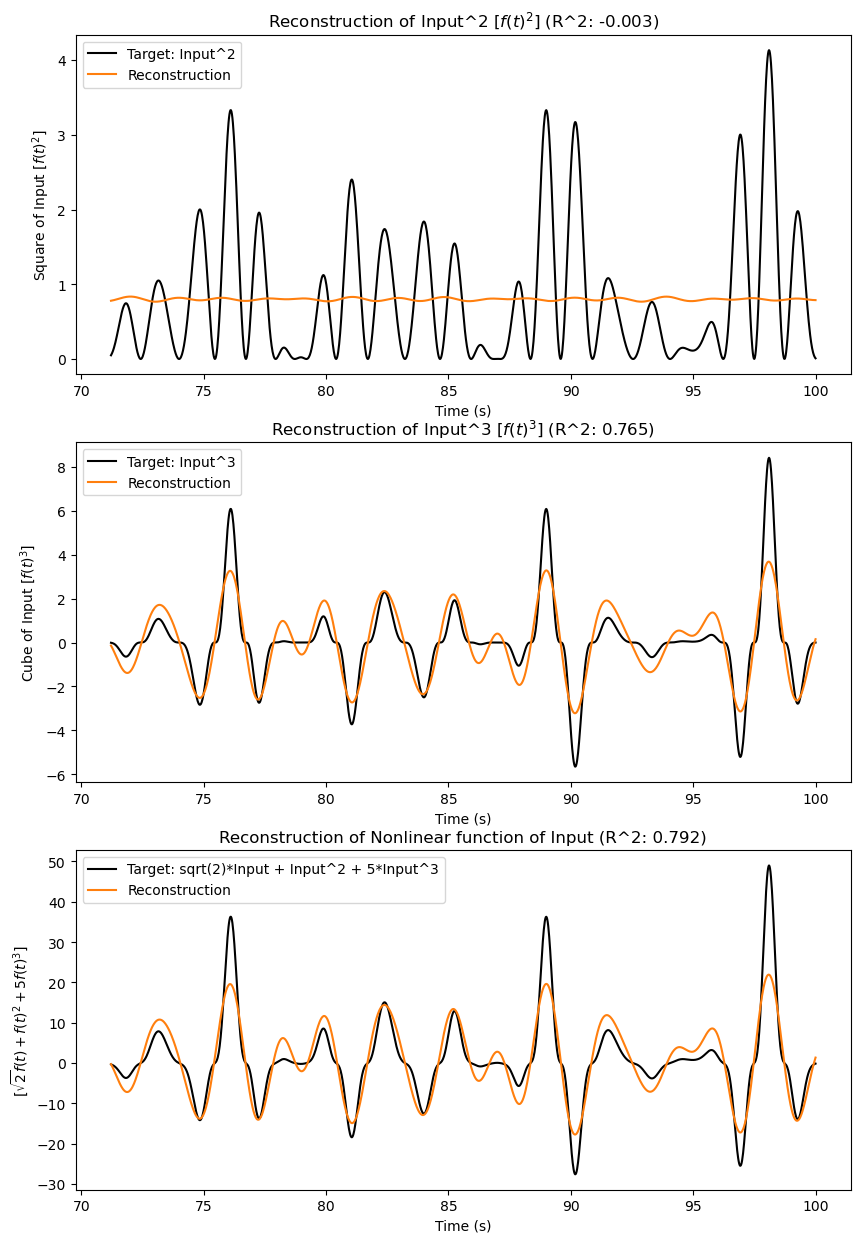

In [12]:
train_fraction = 0.7
ridge_alpha = 2

# Square of the input signal
u_target_1 = u_eval**2
# Cube of the input signal
u_target_2 = u_eval**3

# Sum of nonlinear functions of the input signal
u_target_sum = np.sqrt(2) * u_eval + u_eval**2 + 5*u_eval**3

n_samples_1 = len(u_target_1)
n_samples_2 = len(u_target_2)
n_samples_sum = len(u_target_sum)

train_size_1 = int(train_fraction * n_samples_1)
train_size_2 = int(train_fraction * n_samples_2)
train_size_sum = int(train_fraction * n_samples_sum)

y_test_1, y_pred_1, score_1, _ = __fit__(X_eval, u_target_1, train_size_1, ridge_alpha)
y_test_2, y_pred_2, score_2, _ = __fit__(X_eval, u_target_2, train_size_2, ridge_alpha)
y_test_sum, y_pred_sum, score_sum, _ = __fit__(X_eval, u_target_sum, train_size_sum, ridge_alpha)

fig, ax = plt.subplots(3, 1, figsize=(10, 15))
ax[0].plot(sol.t[washout + train_size_1 : washout + n_samples_1], y_test_1.T, label="Target: Input^2", color="black", linewidth=1.5)
ax[0].plot(sol.t[washout + train_size_1 : washout + n_samples_1], y_pred_1.T, label="Reconstruction", color="tab:orange")
ax[0].set_title(f"Reconstruction of Input^2 $[f(t)^2]$ (R^2: {score_1:.3f})")
ax[0].set_ylabel("Square of Input $[f(t)^2]$")
ax[0].set_xlabel("Time (s)")
ax[0].legend()

ax[1].plot(sol.t[washout + train_size_2 : washout + n_samples_2], y_test_2.T, label="Target: Input^3", color="black", linewidth=1.5)
ax[1].plot(sol.t[washout + train_size_2 : washout + n_samples_2], y_pred_2.T, label="Reconstruction", color="tab:orange")
ax[1].set_title(f"Reconstruction of Input^3 $[f(t)^3]$ (R^2: {score_2:.3f})")
ax[1].set_ylabel("Cube of Input $[f(t)^3]$")
ax[1].set_xlabel("Time (s)")
ax[1].legend()

ax[2].plot(sol.t[washout + train_size_sum : washout + n_samples_sum], y_test_sum.T, label="Target: sqrt(2)*Input + Input^2 + 5*Input^3", color="black", linewidth=1.5)
ax[2].plot(sol.t[washout + train_size_sum : washout + n_samples_sum], y_pred_sum.T, label="Reconstruction", color="tab:orange")
ax[2].set_title(f"Reconstruction of Nonlinear function of Input (R^2: {score_sum:.3f})")
ax[2].set_ylabel("$[\\sqrt{2}f(t) + f(t)^2 + 5f(t)^3]$")
ax[2].set_xlabel("Time (s)")
ax[2].legend()

plt.show()

Here is the catch: this system struggles with nonlinear computations. It can approximate the cube of the input signal, and even the nonlinear combination, to some extent. But we should be careful about what that means. Those target signals swing above and below zero, just like the original input signal. So the system is not being asked to do something completely different in shape. The square of the input is a harder test. Unlike the original signal, it is always positive. 

And these results are not too surprising once we look back at the model. This spring-mass system is linear: if the displacement doubles, the spring force doubles too. That makes it easier to understand, but it also limits the kinds of transformations it can provide.

If we want stronger nonlinear computation, we need to put some nonlinearity into the system itself, such as nonlinear springs or nonlinear damping. Oscillators with nonlinear spring behavior are often modeled as **Duffing oscillators**. They can be more expressive than linear oscillators, but they are also harder to analyze and control.

## Conclusion

Let's summarize what we did in this experiment. We started with one oscillator, connected many oscillators together, and used their collective motion as a simple reservoir. For this toy setup, the reservoir states were useful for reconstructing the input, retaining delayed information, and making short-horizon predictions.

But the final nonlinear test also gave us an important warning: a purely linear oscillator reservoir cannot provide every kind of computation we might want. That limitation is not a dead end. It points directly to the next step: introduce nonlinearity and see how it changes the reservoir's computational behavior.

And that's exactly what we will do in the next experiment. We will take this same setup and add nonlinear springs to see how that changes the reservoir's ability to compute nonlinear functions of the input signal. Stay tuned!